In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
import PIL
import requests

In [2]:
tips = sns.load_dataset('tips')
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

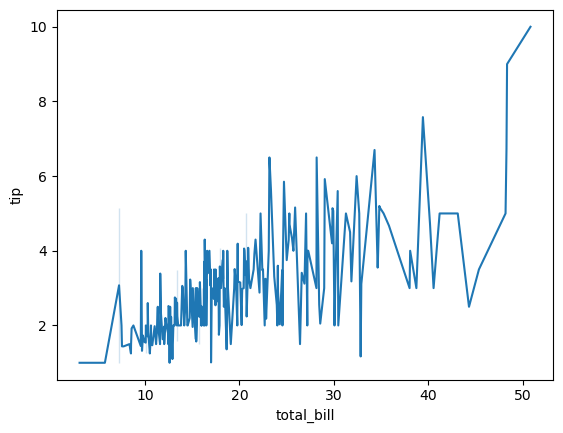

In [4]:
# Basic line plot
sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip',) # define our y variable

<Axes: xlabel='total_bill', ylabel='tip'>

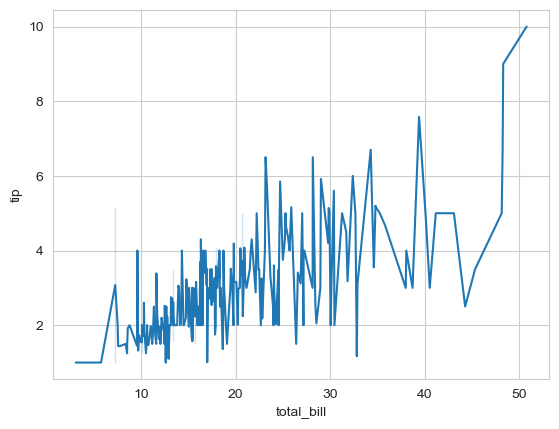

In [7]:
# Basic line plot
sns.set_style('whitegrid')
sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip',) # define our y variable


[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

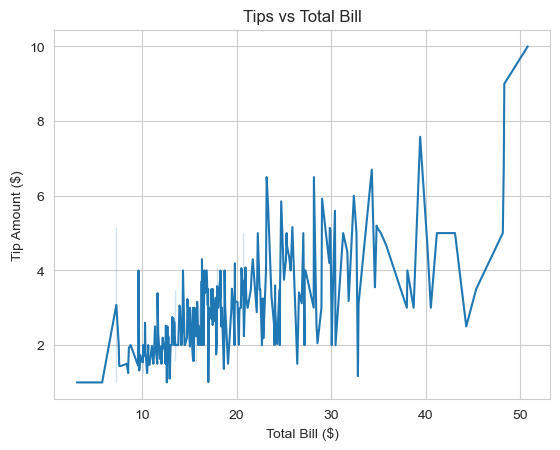

In [10]:
# Basic line plot
tipgraph = sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip',) # define our y variable
tipgraph.set(title = 'Tips vs Total Bill',
                   xlabel = 'Total Bill ($)',
                   ylabel = 'Tip Amount ($)')

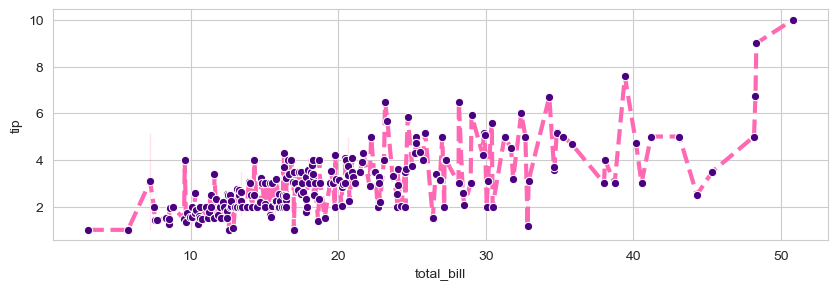

In [12]:
fig = plt.subplots(figsize = (10, 3))
tipgraph = sns.lineplot(data = tips, # Choose our dataset
             x = 'total_bill', # define our x variable
             y = 'tip', # define our y variable
             color = 'hotpink', # change the color of the line
             linestyle = '--', # change the line style'
             linewidth = 3, # change the line width
             marker = 'o', # change the marker
             markerfacecolor = 'indigo',) # change the marker face color
# tipgraph.set(title = 'Tips vs Total Bill',
#                    xlabel = 'Total Bill ($)',
#                    ylabel = 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

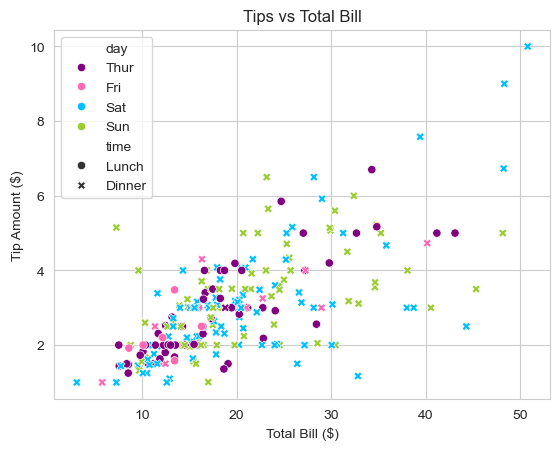

In [ ]:
#  Seaborn makes it very easy to represent multiple variables with different visual elements of our graph

tipgraph = sns.scatterplot(data = tips, # Choose our dataset
                x = 'total_bill', # define our x variable
                y = 'tip', # define our y variable
                style= 'time', # define the style variable
                hue = 'day', # define the hue variable
                palette= ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])
tipgraph.set(title = 'Tips vs Total Bill',
                   xlabel = 'Total Bill ($)',
                   ylabel = 'Tip Amount ($)')

### Pairplot

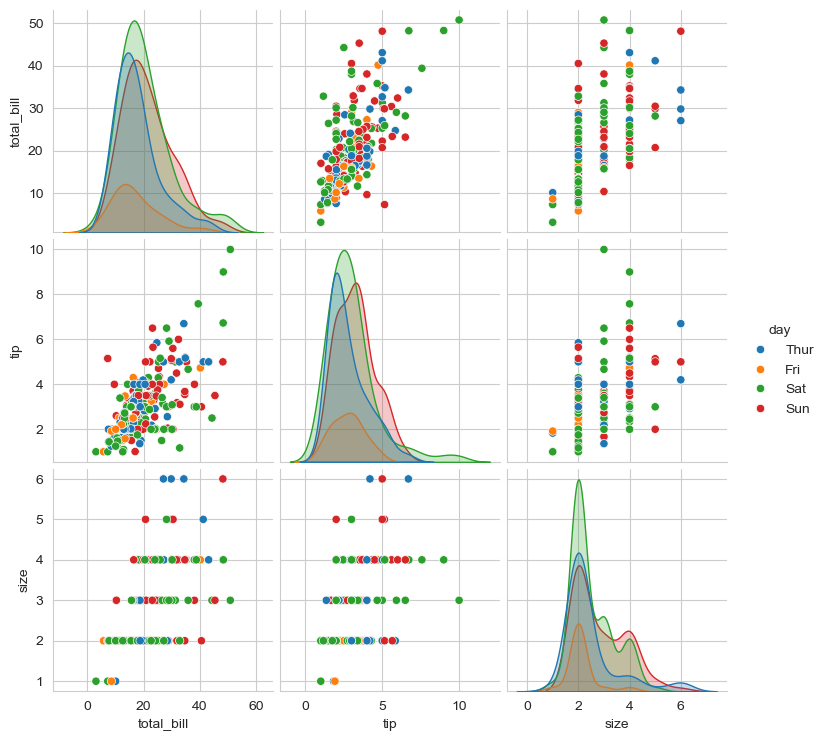

In [ ]:
# pairplot is another convenient way to compare variables
sns.pairplot(data = tips,
             hue = 'day')

### Relplot

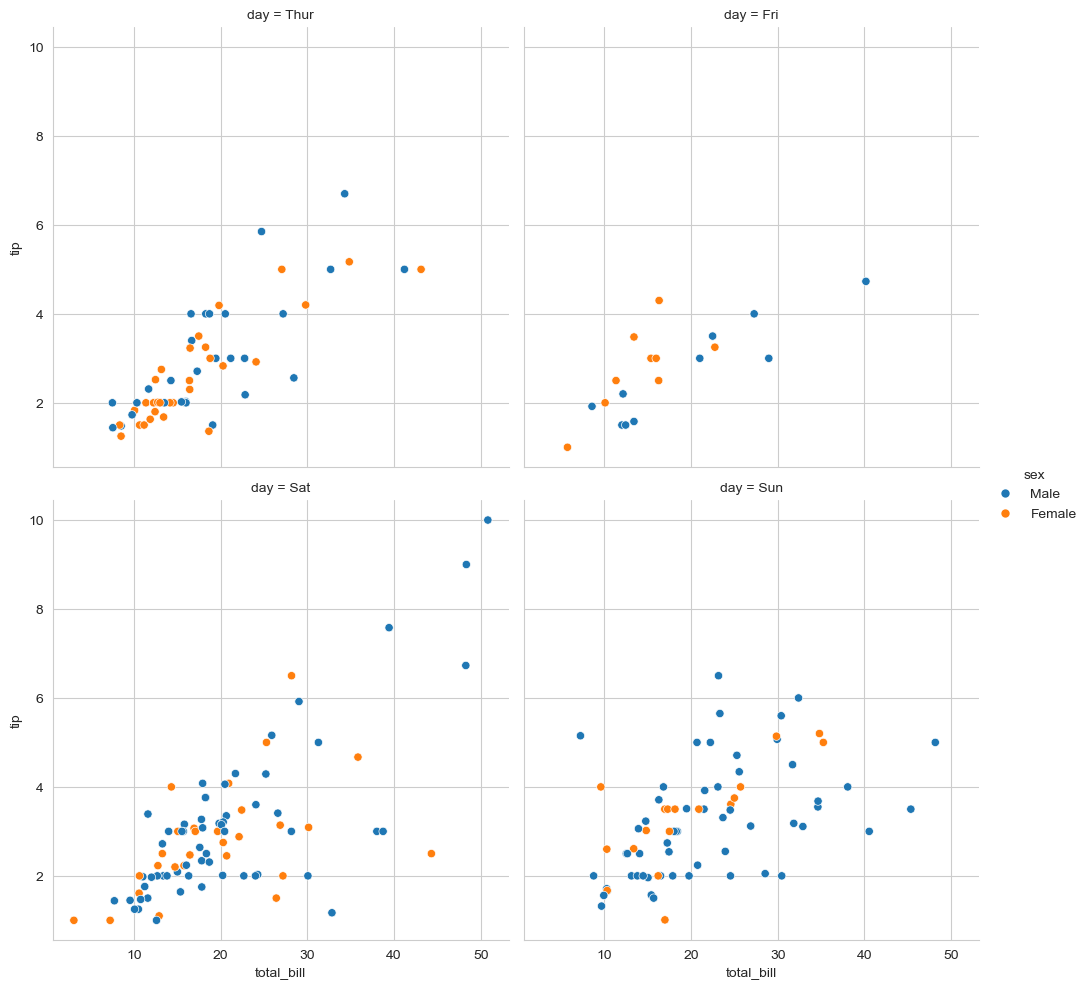

In [16]:
#  relplot also lets us explore  specific levels within variables

daysplot = sns.relplot(data = tips, # Choose our dataset
                x = 'total_bill', # define our x variable
                y = 'tip', # define our y variable
                hue = 'sex', # define the hue variable
                col = 'day', # define the column variable
                kind = 'scatter', # define the kind of plot
                col_wrap = 2,) # define the number of columns
daysplot

# Plotly

In [17]:
import plotly.graph_objects as go     
# 'go' is 'graph objects’
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [18]:
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))


In [ ]:
graph = go.Figure()
# Next, chhose our plot type (bar) and our data
graph.add_trace(go.Bar(x=x1, y=y1))
#Next, update our layout to include titles
graph.update_layout(title_text='Pirate Scores',
                    xaxis_title = 'Pirates',
                    yaxis_title = 'Score')
# Finally, show our plot!
graph.show()

In [20]:
#Customizing plotly graphs
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', 
                           marker=dict(size=15, # point size
                                       color='hotpink',  # point colour
                                       opacity=1,  # point transparency/alpha
                                       line=dict(width=5, color='purple')  # point outline
                                       )))
graph.update_layout(title='Interactive Pirate Plot',
                    xaxis_title='Pirates',
                    yaxis_title='Scores',
                    width=500, height=500)

In [21]:
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv", on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


# Making wordclouds
Weʼll make a simple word cloud using the ‘quoteʼ variable

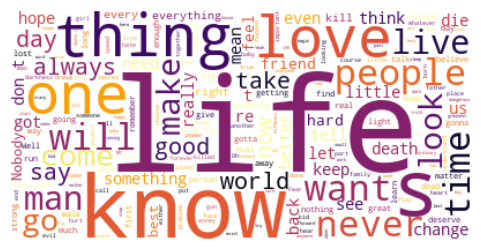

In [23]:
 # join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)
# generate our wordcloud image
wordcloud = WordCloud(background_color="white", colormap = 'inferno').generate(text)
# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes
          interpolation='bilinear')   
ax.axis("off")
plt.show() 

# Making venn diagrams
 - We can use the matplotlib_venn extension to make venn diagrams
 - First import the packag

In [24]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# Making venn diagrams
 Next, assign our sets to each circle and modify the appearanc

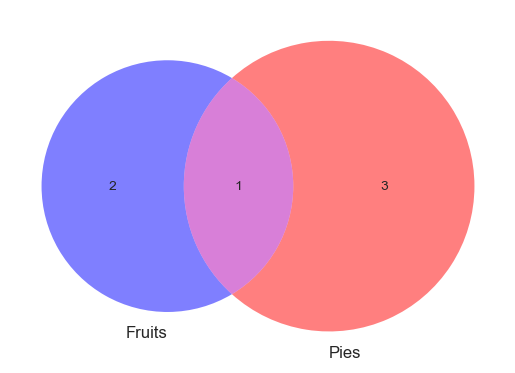

In [ ]:
diagram = venn2([A, B],
                set_labels = ('Fruits', 'Pies'),
                set_colors=("blue", "red"),
                alpha=0.5)
plt.show()

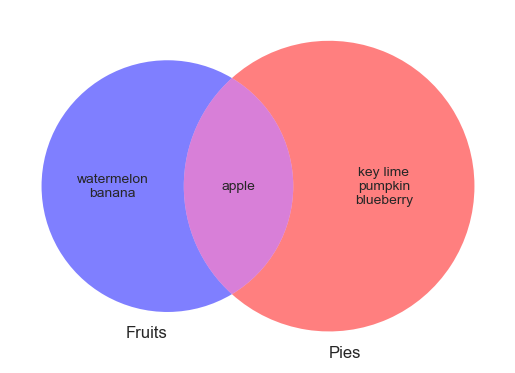

In [29]:
diagram = venn2([A, B],
                set_labels = ('Fruits', 'Pies'),
                set_colors=("blue", "red"),
                alpha=0.5)
diagram.get_label_by_id("10").set_text("\n".join(A - B))# left
diagram.get_label_by_id("11").set_text("\n".join(A & B))# middle
diagram.get_label_by_id("01").set_text("\n".join(B - A))# right
plt.show()
